# Marketing Mix Modeling

## Objective
Quantify the incremental impact of each marketing channel on lead generation using a regression-based Marketing Mix Model. The analysis produces channel-level ROI estimates, identifies diminishing returns via Hill saturation curves, and recommends budget reallocations grounded in marginal ROI.

## Dataset
- **Grain**: Weekly observations (104 weeks / 2 years)
- **Channels**: TV, Radio, Paid Search, Paid Social, OOH (billboards), OTT (streaming), SEO
- **Outcomes**: Leads, Signed Cases, Revenue
- **Controls**: Unemployment rate, competitor spend index, federal holidays

## Methodology
1. **Adstock transformation** — captures carryover effects with channel-specific decay rates optimized via grid search on the training set
2. **Hill saturation** — models diminishing returns with a flexible Hill function
3. **Control variables** — seasonality (sin/cos encoding), trend, unemployment, competitor spend, holidays
4. **Model selection** — OLS vs Ridge regression compared via time-series cross-validation
5. **Diagnostics** — VIF, residual analysis, Newey-West HAC standard errors, coefficient sign checks
6. **ROI & optimization** — channel decomposition, average vs marginal ROI, budget reallocation simulation

> **Note:** The dataset is synthetic. Model fit and coefficient estimates reflect the data-generation process rather than real-world marketing dynamics.

## Modeling Target: Leads vs Revenue

This notebook models `leads` as the target variable.

| Target | Pros | Cons |
|--------|------|------|
| **Leads** | Closer to marketing touchpoints, less noise | Doesn't capture lead quality or conversion rates |
| **Revenue** | Direct business impact, what stakeholders care about | More confounders (sales team, pricing, product), longer lag |

In practice, modeling both targets reveals whether a channel drives volume (leads) or value (revenue). If a channel drives leads but not revenue, it signals a lead-quality problem worth investigating.

## 1. Data Exploration

In [1]:
# Import libraries you'll need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Additional libraries used in later steps (install if needed):
# - statsmodels: pip install statsmodels
#   Used for: OLS regression, VIF calculation, Ljung-Box test, HAC standard errors
# - scikit-learn: pip install scikit-learn
#   Used for: Ridge regression, train/test split, scaling, cross-validation
# - scipy: pip install scipy
#   Used for: Statistical tests (Shapiro-Wilk, correlation)

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Load the data
# It simulates 2 years of weekly marketing data for a law firm with realistic patterns:
# - Seasonality (legal services peak after holidays)
# - Channel-specific spend distributions
# - Leads generated based on channel effectiveness with diminishing returns and carryover effects
# See generate_datasets.py for the full generation logic.

df = pd.read_csv('01_marketing_mix_modeling.csv', parse_dates=['week_start'])
print(f"Data loaded: {len(df)} rows")

Data loaded: 104 rows


In [3]:
# Explore: shape, dtypes, head, describe
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nFirst 5 rows:")
display(df.head())
print("\nSummary Statistics:")
display(df.describe())

Shape: (104, 14)

Data Types:
week_start                datetime64[ns]
tv_spend                         float64
radio_spend                      float64
paid_search_spend                float64
paid_social_spend                float64
ooh_spend                        float64
ott_spend                        float64
seo_investment                   float64
total_spend                      float64
leads                              int64
signed_cases                       int64
revenue                          float64
competitor_spend_index           float64
unemployment_rate                float64
dtype: object

First 5 rows:


,week_start,tv_spend,radio_spend,paid_search_spend,paid_social_spend,ooh_spend,ott_spend,seo_investment,total_spend,leads,signed_cases,revenue,competitor_spend_index,unemployment_rate
0,2022-01-03,32980.28,7723.47,16943.07,8284.54,3765.85,4648.79,3789.61,78135.61,225,34,249500.29,87.3,4.3
1,2022-01-10,26848.98,2774.90,17851.11,7224.67,2476.12,4357.93,2628.80,64162.51,199,45,189934.14,88.0,4.8
2,2022-01-17,26733.70,8221.85,11547.02,6563.55,3399.36,4562.46,2699.15,63727.08,214,34,252711.88,116.4,4.1
3,2022-01-24,29966.83,5469.76,18275.98,10167.47,5193.64,5327.96,3440.88,77842.52,211,37,197336.23,113.1,4.4
4,2022-01-31,32061.71,4473.92,15972.25,5422.38,3323.08,5917.51,3515.50,70686.35,219,49,396197.74,84.6,5.7



Summary Statistics:


,week_start,tv_spend,radio_spend,paid_search_spend,paid_social_spend,ooh_spend,ott_spend,seo_investment,total_spend,leads,signed_cases,revenue,competitor_spend_index,unemployment_rate
count,104,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000
mean,2022-12-29 12:00:00,26873.319808,8267.143558,15572.922115,5967.852788,3952.712212,5159.629519,2993.972308,68787.552788,195.500000,37.894231,321307.951923,100.472115,4.679808
min,2022-01-03 00:00:00,16075.580000,2774.900000,8933.060000,2769.910000,758.730000,1364.180000,2087.970000,48127.620000,156.000000,27.000000,107595.180000,80.400000,3.500000
25%,2022-07-02 06:00:00,23733.945000,6478.015000,13438.980000,4749.837500,3380.667500,4403.320000,2672.837500,64244.440000,180.750000,34.000000,249228.530000,87.900000,4.100000
50%,2022-12-29 12:00:00,26490.740000,8286.470000,15940.080000,5756.405000,3984.560000,5130.560000,2995.190000,68495.300000,194.000000,37.000000,303638.820000,101.650000,4.700000
75%,2023-06-27 18:00:00,30173.367500,10093.930000,17322.200000,7095.715000,4802.822500,6154.137500,3319.267500,73738.922500,210.250000,42.000000,385156.437500,112.600000,5.300000
max,2023-12-25 00:00:00,45861.430000,15705.460000,22301.540000,10167.470000,6573.360000,8406.040000,4149.450000,92769.480000,234.000000,52.000000,589135.500000,119.900000,6.000000
std,NaN,5485.497489,2342.649659,2806.816193,1624.476261,1043.107528,1433.671957,455.575822,7153.649545,18.272479,5.870642,97484.217618,12.810701,0.740556


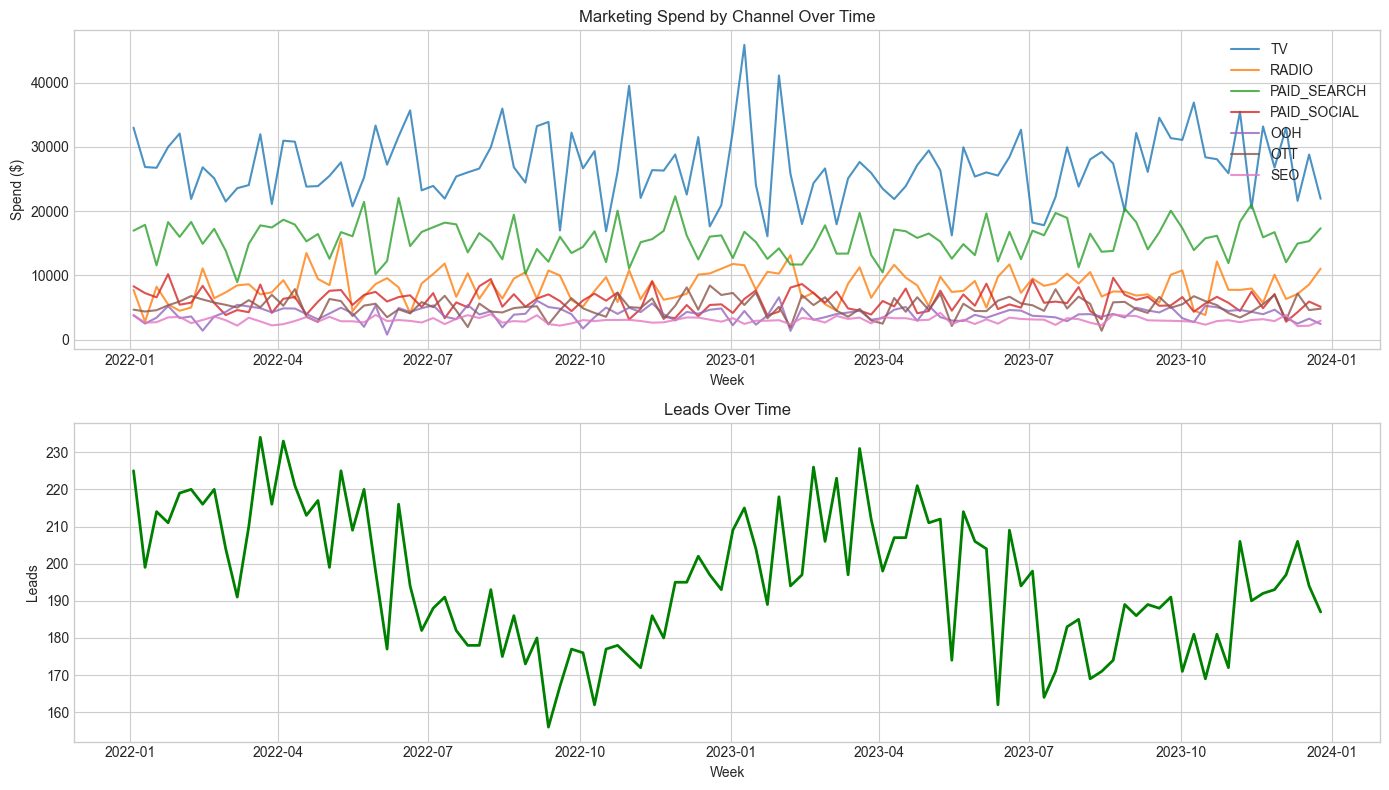

In [4]:
# Visualize spend over time (line plot with multiple channels)
spend_cols = ['tv_spend', 'radio_spend', 'paid_search_spend', 'paid_social_spend', 'ooh_spend', 'ott_spend', 'seo_investment']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for col in spend_cols:
    axes[0].plot(df['week_start'], df[col], label=col.replace('_spend', '').replace('_investment', '').upper(), alpha=0.8)
axes[0].set_title('Marketing Spend by Channel Over Time')
axes[0].set_xlabel('Week')
axes[0].set_ylabel('Spend ($)')
axes[0].legend(loc='upper right')

axes[1].plot(df['week_start'], df['leads'], color='green', linewidth=2)
axes[1].set_title('Leads Over Time')
axes[1].set_xlabel('Week')
axes[1].set_ylabel('Leads')

plt.tight_layout()
plt.show()

---
## 2. Correlation Analysis

Correlation between spend variables and outcomes provides an initial signal but cannot establish channel effectiveness — it ignores confounding, carryover, and diminishing returns. Treat this step as exploratory only.

In [5]:
# Calculate correlation matrix
outcome_cols = ['leads', 'signed_cases', 'revenue']
corr_matrix = df[spend_cols + outcome_cols].corr()

print("Correlation Matrix:")
display(corr_matrix)

Correlation Matrix:


,tv_spend,radio_spend,paid_search_spend,paid_social_spend,ooh_spend,ott_spend,seo_investment,leads,signed_cases,revenue
tv_spend,1.000000,-0.058101,-0.011317,-0.062456,0.116766,-0.034221,0.064636,0.085663,0.162196,0.121217
radio_spend,-0.058101,1.000000,-0.103126,-0.042034,0.099208,-0.021577,-0.009213,0.000978,-0.138150,0.024112
paid_search_spend,-0.011317,-0.103126,1.000000,0.146190,0.021875,0.243444,-0.022542,0.229844,0.221697,0.174117
paid_social_spend,-0.062456,-0.042034,0.146190,1.000000,0.038028,0.123030,0.274045,0.105343,0.007625,0.048497
ooh_spend,0.116766,0.099208,0.021875,0.038028,1.000000,0.083382,0.145892,-0.001349,-0.104064,-0.086327
ott_spend,-0.034221,-0.021577,0.243444,0.123030,0.083382,1.000000,0.045180,0.177684,0.035525,0.010286
seo_investment,0.064636,-0.009213,-0.022542,0.274045,0.145892,0.045180,1.000000,0.183453,0.079971,0.044933
leads,0.085663,0.000978,0.229844,0.105343,-0.001349,0.177684,0.183453,1.000000,0.409406,0.182563
signed_cases,0.162196,-0.138150,0.221697,0.007625,-0.104064,0.035525,0.079971,0.409406,1.000000,0.514844
revenue,0.121217,0.024112,0.174117,0.048497,-0.086327,0.010286,0.044933,0.182563,0.514844,1.000000


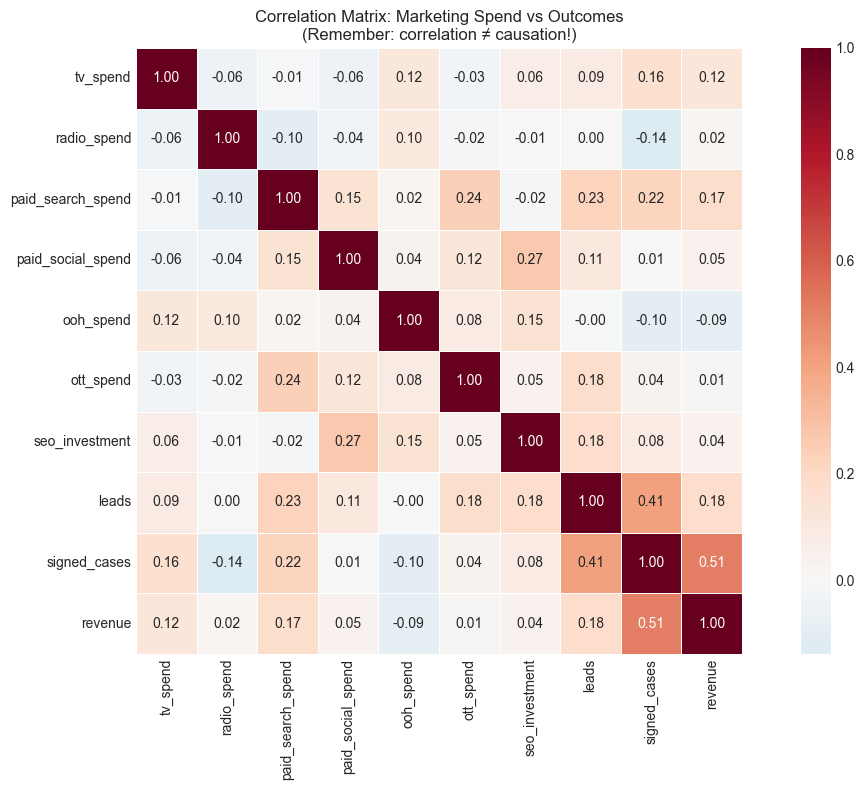


Correlation with Leads (sorted):
signed_cases         0.409406
paid_search_spend    0.229844
seo_investment       0.183453
revenue              0.182563
ott_spend            0.177684
paid_social_spend    0.105343
tv_spend             0.085663
radio_spend          0.000978
ooh_spend           -0.001349
Name: leads, dtype: float64


In [6]:
# Create a heatmap visualization
fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix: Marketing Spend vs Outcomes\n(Remember: correlation ≠ causation!)')

plt.tight_layout()
plt.show()

print("\nCorrelation with Leads (sorted):")
print(corr_matrix['leads'].drop('leads').sort_values(ascending=False))

---
## 3. Feature Engineering — Adstock (Carryover Effects)

Marketing channels produce effects that persist beyond the week of spend. The adstock transformation captures this carryover:

`adstock_t = spend_t + decay_rate * adstock_{t-1}`

Decay rates are channel-specific — brand channels (TV, OOH) carry over longer than direct-response channels (Paid Search, Paid Social). Optimal decay rates are selected via grid search on the training set to prevent data leakage.

In [7]:
# Step 3a: Create adstock transformation function

def apply_adstock(series, decay_rate):
    """
    Apply adstock transformation to capture carryover effects.
    Formula: adstock_t = spend_t + decay_rate * adstock_{t-1}
    
    Args:
        series: pandas Series of spend values
        decay_rate: float between 0-1 (higher = longer carryover)
    Returns:
        pandas Series with adstocked values
    """
    adstocked = [series.iloc[0]]
    for i in range(1, len(series)):
        adstocked.append(series.iloc[i] + decay_rate * adstocked[i-1])
    return pd.Series(adstocked, index=series.index)

print("Adstock function created!")

Adstock function created!


In [8]:
# Step 3b: Define industry standard decay rate ranges

decay_constraints = {
    'tv_spend': (0.6, 0.9),
    'radio_spend': (0.4, 0.8),
    'ooh_spend': (0.5, 0.9),
    'ott_spend': (0.5, 0.9),
    'paid_search_spend': (0.1, 0.5),
    'paid_social_spend': (0.1, 0.5),
    'seo_investment': (0.3, 0.7),
}

print("Decay constraints defined:")
for channel, (min_d, max_d) in decay_constraints.items():
    print(f"  {channel}: [{min_d}, {max_d}]")

Decay constraints defined:
  tv_spend: [0.6, 0.9]
  radio_spend: [0.4, 0.8]
  ooh_spend: [0.5, 0.9]
  ott_spend: [0.5, 0.9]
  paid_search_spend: [0.1, 0.5]
  paid_social_spend: [0.1, 0.5]
  seo_investment: [0.3, 0.7]


In [9]:
# Step 3c: Grid search function to find optimal decay rate
# IMPORTANT: Only use training data (first 80%) to avoid data leakage

from scipy.stats import pearsonr

def find_optimal_decay(channel_name, spend_series, outcome_series, train_idx=None, step=0.05):
    """
    Grid search to find the decay rate that maximizes correlation with outcome.
    Uses decay_constraints dict to get min/max range for the channel.
    
    Args:
        channel_name: Name of the channel (key in decay_constraints)
        spend_series: Full spend series (adstock applied to all data)
        outcome_series: Full outcome series
        train_idx: Indices to use for correlation calculation (to avoid data leakage)
                   If None, uses all data (not recommended)
        step: Step size for decay rate grid
    
    Returns:
        DataFrame with decay rates and their correlations
    """
    min_decay, max_decay = decay_constraints[channel_name]
    decay_range = np.arange(min_decay, max_decay + step, step)
    
    results = []
    for decay in decay_range:
        adstocked = apply_adstock(spend_series, decay)
        # Only use training indices for correlation calculation
        if train_idx is not None:
            corr, _ = pearsonr(adstocked.iloc[train_idx], outcome_series.iloc[train_idx])
        else:
            corr, _ = pearsonr(adstocked, outcome_series)
        results.append({'decay': round(decay, 2), 'correlation': round(corr, 4)})
    return pd.DataFrame(results)

print("Grid search function created (with train-only option to prevent data leakage)!")

Grid search function created (with train-only option to prevent data leakage)!


In [10]:
# Step 3d: Find optimal decay rate for each channel
# USING TRAINING DATA ONLY (first 80%) to prevent data leakage

# Define training indices (first 80% of data)
train_end_idx = int(len(df) * 0.8)
train_indices = list(range(train_end_idx))

optimal_decays = {}

print("Finding optimal decay rates via constrained grid search...")
print("(Using TRAINING DATA ONLY - first 80% of rows to prevent data leakage)")
print("-" * 65)

for col in spend_cols:
    results = find_optimal_decay(col, df[col], df['leads'], train_idx=train_indices)
    best = results.loc[results['correlation'].idxmax()]
    optimal_decays[col] = best['decay']
    
    min_d, max_d = decay_constraints[col]
    print(f"{col:25s}: {best['decay']:.2f} (corr: {best['correlation']:.4f}) range: [{min_d}-{max_d}]")

print(f"\nNote: Decay rates selected using only weeks 1-{train_end_idx} (training set)")

Finding optimal decay rates via constrained grid search...
(Using TRAINING DATA ONLY - first 80% of rows to prevent data leakage)
-----------------------------------------------------------------
tv_spend                 : 0.60 (corr: -0.1410) range: [0.6-0.9]
radio_spend              : 0.40 (corr: -0.0640) range: [0.4-0.8]
paid_search_spend        : 0.10 (corr: 0.2691) range: [0.1-0.5]
paid_social_spend        : 0.10 (corr: 0.1005) range: [0.1-0.5]
ooh_spend                : 0.50 (corr: -0.0824) range: [0.5-0.9]
ott_spend                : 0.50 (corr: 0.1616) range: [0.5-0.9]
seo_investment           : 0.30 (corr: 0.1299) range: [0.3-0.7]

Note: Decay rates selected using only weeks 1-83 (training set)


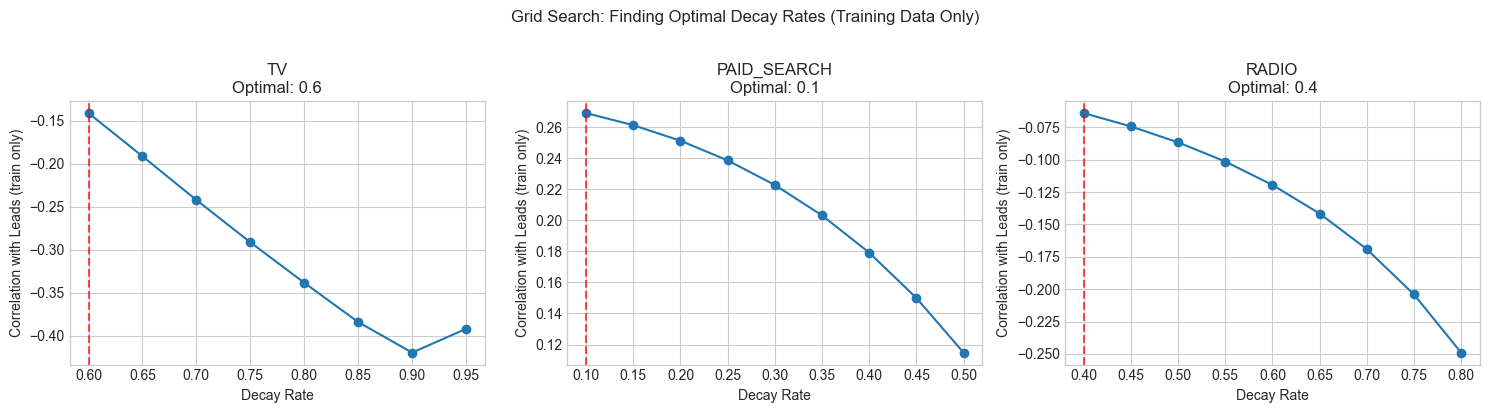

In [11]:
# Step 3e: Visualize grid search results for select channels
# (Using training data only for correlation calculation)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['tv_spend', 'paid_search_spend', 'radio_spend']):
    results = find_optimal_decay(col, df[col], df['leads'], train_idx=train_indices)
    best_decay = results.loc[results['correlation'].idxmax(), 'decay']
    
    ax.plot(results['decay'], results['correlation'], marker='o')
    ax.axvline(x=best_decay, color='red', linestyle='--', alpha=0.7)
    ax.set_xlabel('Decay Rate')
    ax.set_ylabel('Correlation with Leads (train only)')
    ax.set_title(f'{col.replace("_spend", "").replace("_investment", "").upper()}\nOptimal: {best_decay}')

plt.suptitle('Grid Search: Finding Optimal Decay Rates (Training Data Only)', y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# Step 3f: Apply adstock to each channel using optimal decay rates

for col, decay in optimal_decays.items():
    df[f'{col}_adstock'] = apply_adstock(df[col], decay)

print("Adstock applied to all channels:")
for col, decay in optimal_decays.items():
    print(f"  {col} → {col}_adstock (decay={decay})")

# Preview the result
print("\nPreview - TV Spend vs Adstocked TV Spend:")
display(df[['week_start', 'tv_spend', 'tv_spend_adstock']].head(10))

Adstock applied to all channels:
  tv_spend → tv_spend_adstock (decay=0.6)
  radio_spend → radio_spend_adstock (decay=0.4)
  paid_search_spend → paid_search_spend_adstock (decay=0.1)
  paid_social_spend → paid_social_spend_adstock (decay=0.1)
  ooh_spend → ooh_spend_adstock (decay=0.5)
  ott_spend → ott_spend_adstock (decay=0.5)
  seo_investment → seo_investment_adstock (decay=0.3)

Preview - TV Spend vs Adstocked TV Spend:


,week_start,tv_spend,tv_spend_adstock
0,2022-01-03,32980.28,32980.280000
1,2022-01-10,26848.98,46637.148000
2,2022-01-17,26733.70,54715.988800
3,2022-01-24,29966.83,62796.423280
4,2022-01-31,32061.71,69739.563968
5,2022-02-07,21882.61,63726.348381
6,2022-02-14,26806.98,65042.789028
7,2022-02-21,25095.00,64120.673417
8,2022-02-28,21489.73,59962.134050
9,2022-03-07,23554.32,59531.600430


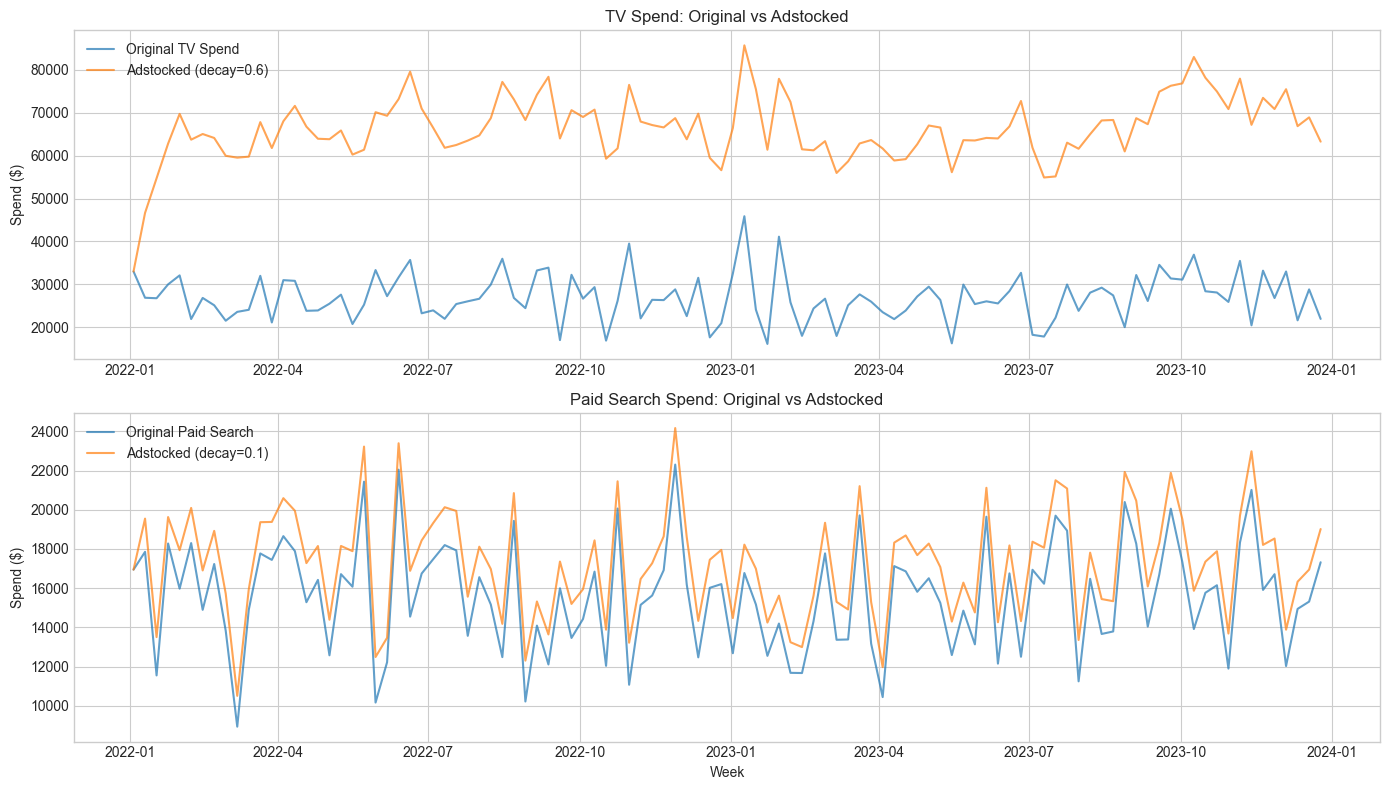

TV (brand) has higher decay → more carryover → smoother, higher adstock curve
Paid Search (direct response) has lower decay → less carryover → stays closer to original


In [13]:
# Step 3g: Visualize original spend vs adstocked spend

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# TV: high decay (brand building)
tv_decay = optimal_decays['tv_spend']
axes[0].plot(df['week_start'], df['tv_spend'], label='Original TV Spend', alpha=0.7)
axes[0].plot(df['week_start'], df['tv_spend_adstock'], label=f'Adstocked (decay={tv_decay})', alpha=0.7)
axes[0].set_title('TV Spend: Original vs Adstocked')
axes[0].set_ylabel('Spend ($)')
axes[0].legend()

# Paid Search: low decay (direct response)
ps_decay = optimal_decays['paid_search_spend']
axes[1].plot(df['week_start'], df['paid_search_spend'], label='Original Paid Search', alpha=0.7)
axes[1].plot(df['week_start'], df['paid_search_spend_adstock'], label=f'Adstocked (decay={ps_decay})', alpha=0.7)
axes[1].set_title('Paid Search Spend: Original vs Adstocked')
axes[1].set_xlabel('Week')
axes[1].set_ylabel('Spend ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("TV (brand) has higher decay → more carryover → smoother, higher adstock curve")
print("Paid Search (direct response) has lower decay → less carryover → stays closer to original")

---
## 4. Feature Engineering — Saturation (Diminishing Returns)

Spending has diminishing returns — the first dollar is more effective than the hundred-thousandth. The Hill function models this nonlinearity:

`H(x) = x^alpha / (x^alpha + K^alpha)`

where K is the half-saturation point (spend level at 50% of maximum effect). The Hill function bounds the effect between 0 and 1 and is the standard approach in professional MMM implementations.

In [14]:
# Step 4a: Hill function for saturation (diminishing returns)

def hill_transform(x, alpha=0.5, K=None):
    """
    Hill function to model diminishing returns.
    Formula: x^alpha / (x^alpha + K^alpha)
    
    Args:
        x: spend values (Series or array)
        alpha: shape parameter (0-1 = steep early saturation, >1 = S-curve)
        K: half-saturation point (spend level at 50% of max effect)
           If None, uses median of x
    Returns:
        Transformed values between 0 and 1
    """
    if K is None:
        K = np.median(x)
    return (x ** alpha) / (x ** alpha + K ** alpha)

# Apply Hill transform to adstocked spend columns
adstock_cols = [col for col in df.columns if col.endswith('_adstock')]

for col in adstock_cols:
    df[f'{col}_saturated'] = hill_transform(df[col], alpha=0.5)

print("Hill saturation applied to adstocked columns:")
for col in adstock_cols:
    print(f"  {col} → {col}_saturated")

Hill saturation applied to adstocked columns:
  tv_spend_adstock → tv_spend_adstock_saturated
  radio_spend_adstock → radio_spend_adstock_saturated
  paid_search_spend_adstock → paid_search_spend_adstock_saturated
  paid_social_spend_adstock → paid_social_spend_adstock_saturated
  ooh_spend_adstock → ooh_spend_adstock_saturated
  ott_spend_adstock → ott_spend_adstock_saturated
  seo_investment_adstock → seo_investment_adstock_saturated


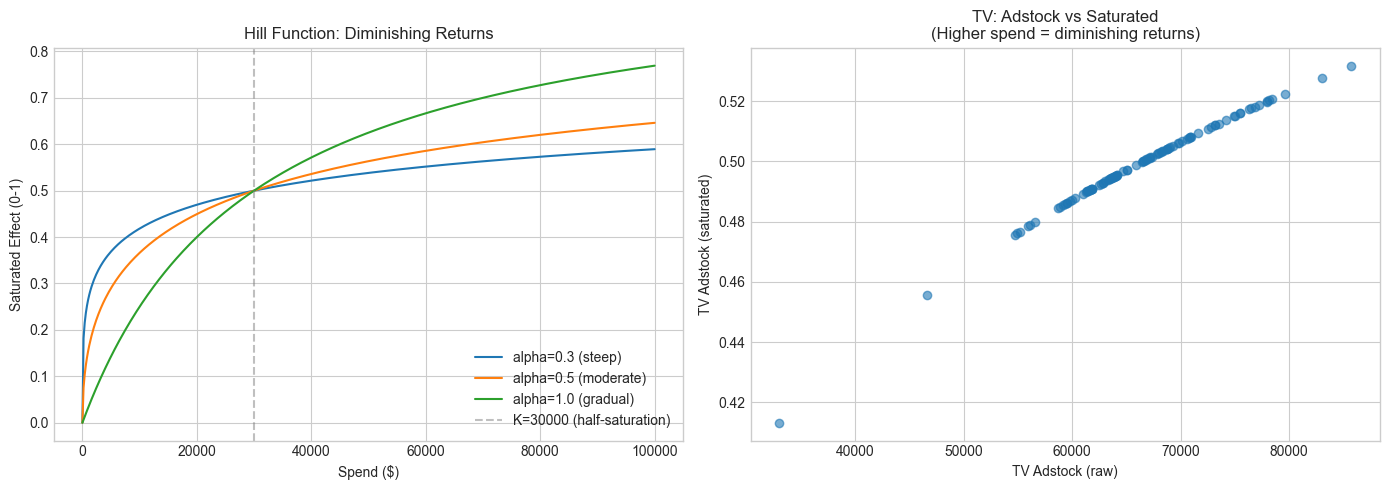

The Hill function ensures that doubling spend does NOT double the effect.
This captures real-world diminishing returns in marketing.


In [15]:
# Step 4b: Visualize the Hill saturation curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Show the Hill curve shape
x_range = np.linspace(0, 100000, 500)
K = 30000  # example half-saturation point

axes[0].plot(x_range, hill_transform(x_range, alpha=0.3, K=K), label='alpha=0.3 (steep)')
axes[0].plot(x_range, hill_transform(x_range, alpha=0.5, K=K), label='alpha=0.5 (moderate)')
axes[0].plot(x_range, hill_transform(x_range, alpha=1.0, K=K), label='alpha=1.0 (gradual)')
axes[0].axvline(x=K, color='gray', linestyle='--', alpha=0.5, label=f'K={K} (half-saturation)')
axes[0].set_xlabel('Spend ($)')
axes[0].set_ylabel('Saturated Effect (0-1)')
axes[0].set_title('Hill Function: Diminishing Returns')
axes[0].legend()

# Right: Compare original adstock vs saturated for TV
axes[1].scatter(df['tv_spend_adstock'], df['tv_spend_adstock_saturated'], alpha=0.6)
axes[1].set_xlabel('TV Adstock (raw)')
axes[1].set_ylabel('TV Adstock (saturated)')
axes[1].set_title('TV: Adstock vs Saturated\n(Higher spend = diminishing returns)')

plt.tight_layout()
plt.show()

print("The Hill function ensures that doubling spend does NOT double the effect.")
print("This captures real-world diminishing returns in marketing.")

---
## 5. Control Variables — Seasonality, Trend & External Factors

Without controls, the model risks attributing seasonal demand patterns or macroeconomic shifts to marketing spend. Included controls:

- **Seasonality**: Sin/cos encoding of month (captures cyclical patterns without dummy-variable explosion)
- **Trend**: Week counter for overall growth/decline
- **Unemployment rate**: Macroeconomic demand factor
- **Competitor spend index**: Competitive pressure
- **Federal holidays**: Demand spikes/dips around holidays

In [16]:
# Step 5a: Create seasonality features using sin/cos encoding
# This captures cyclical patterns without needing 12 dummy variables

df['month'] = df['week_start'].dt.month
df['week_of_year'] = df['week_start'].dt.isocalendar().week.astype(int)

# Sin/cos encoding for seasonality (captures cyclical nature)
df['season_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['season_cos'] = np.cos(2 * np.pi * df['month'] / 12)

print("Seasonality features created:")
print("  season_sin, season_cos (cyclical encoding of month)")
display(df[['week_start', 'month', 'season_sin', 'season_cos']].head(10))

Seasonality features created:
  season_sin, season_cos (cyclical encoding of month)


,week_start,month,season_sin,season_cos
0,2022-01-03,1,0.500000,8.660254e-01
1,2022-01-10,1,0.500000,8.660254e-01
2,2022-01-17,1,0.500000,8.660254e-01
3,2022-01-24,1,0.500000,8.660254e-01
4,2022-01-31,1,0.500000,8.660254e-01
5,2022-02-07,2,0.866025,5.000000e-01
6,2022-02-14,2,0.866025,5.000000e-01
7,2022-02-21,2,0.866025,5.000000e-01
8,2022-02-28,2,0.866025,5.000000e-01
9,2022-03-07,3,1.000000,6.123234e-17


In [17]:
# Step 5b: Create trend feature and identify external control variables

# Trend: simple week counter (captures overall growth/decline)
df['trend'] = range(len(df))

# External factors already in dataset:
# - unemployment_rate: economic conditions
# - competitor_spend_index: competitive pressure

# Step 5b-extra: Add US Federal Holidays as a control variable
# Holidays can affect marketing effectiveness (people are off work, different behavior)

from pandas.tseries.holiday import USFederalHolidayCalendar

# Get all US federal holidays in our date range
cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=df['week_start'].min(), end=df['week_start'].max() + pd.Timedelta(days=7))

# Create is_holiday_week: 1 if the week contains a federal holiday, 0 otherwise
def week_has_holiday(week_start, holidays):
    """Check if any holiday falls within the week starting on week_start."""
    week_end = week_start + pd.Timedelta(days=6)
    return int(any((holidays >= week_start) & (holidays <= week_end)))

df['is_holiday_week'] = df['week_start'].apply(lambda x: week_has_holiday(x, holidays))

print(f"Holiday weeks identified: {df['is_holiday_week'].sum()} out of {len(df)} weeks")
print(f"\nSample holiday weeks:")
display(df[df['is_holiday_week'] == 1][['week_start', 'is_holiday_week']].head(10))

# Define control columns (now including holidays)
control_cols = ['season_sin', 'season_cos', 'trend', 'unemployment_rate', 'competitor_spend_index', 'is_holiday_week']

print(f"\nControl variables ({len(control_cols)}):")
for col in control_cols:
    print(f"  {col}")

print(f"\nThese will be added to the model alongside marketing features.")

Holiday weeks identified: 21 out of 104 weeks

Sample holiday weeks:


,week_start,is_holiday_week
2,2022-01-17,1
7,2022-02-21,1
21,2022-05-30,1
24,2022-06-20,1
26,2022-07-04,1
35,2022-09-05,1
40,2022-10-10,1
44,2022-11-07,1
46,2022-11-21,1
51,2022-12-26,1



Control variables (6):
  season_sin
  season_cos
  trend
  unemployment_rate
  competitor_spend_index
  is_holiday_week

These will be added to the model alongside marketing features.


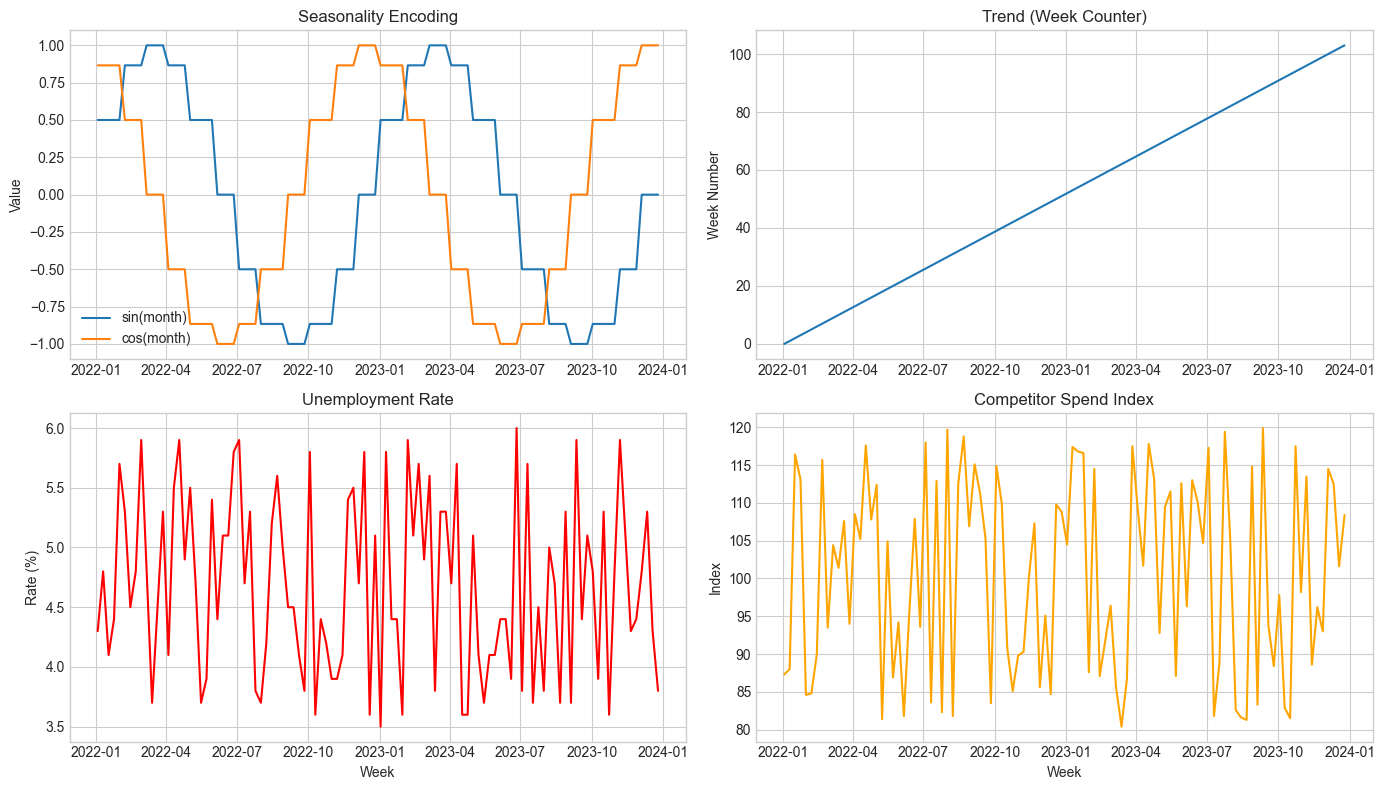

In [18]:
# Step 5c: Visualize seasonality and trend

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Seasonality encoding
axes[0, 0].plot(df['week_start'], df['season_sin'], label='sin(month)')
axes[0, 0].plot(df['week_start'], df['season_cos'], label='cos(month)')
axes[0, 0].set_title('Seasonality Encoding')
axes[0, 0].set_ylabel('Value')
axes[0, 0].legend()

# Trend
axes[0, 1].plot(df['week_start'], df['trend'])
axes[0, 1].set_title('Trend (Week Counter)')
axes[0, 1].set_ylabel('Week Number')

# Unemployment rate
axes[1, 0].plot(df['week_start'], df['unemployment_rate'], color='red')
axes[1, 0].set_title('Unemployment Rate')
axes[1, 0].set_ylabel('Rate (%)')
axes[1, 0].set_xlabel('Week')

# Competitor spend index
axes[1, 1].plot(df['week_start'], df['competitor_spend_index'], color='orange')
axes[1, 1].set_title('Competitor Spend Index')
axes[1, 1].set_ylabel('Index')
axes[1, 1].set_xlabel('Week')

plt.tight_layout()
plt.show()

---
## 6. Train/Test Split

For time-series data, the split must be chronological — the last 20% of observations form the test set. This simulates the real use case of predicting future performance. Additionally, time-series cross-validation with expanding windows provides more robust evaluation.

In [19]:
# Step 6a: Define features (X) and target (y)

# Marketing features: saturated adstock columns
marketing_cols = [col for col in df.columns if col.endswith('_saturated')]

# Control features: seasonality, trend, external factors, holidays
control_cols = ['season_sin', 'season_cos', 'trend', 'unemployment_rate', 'competitor_spend_index', 'is_holiday_week']

# Combine all features
feature_cols = marketing_cols + control_cols

X = df[feature_cols]
y = df['leads']

print(f"Marketing features ({len(marketing_cols)}):")
for col in marketing_cols:
    print(f"  {col}")

print(f"\nControl features ({len(control_cols)}):")
for col in control_cols:
    print(f"  {col}")

print(f"\nTotal features: {len(feature_cols)}")
print(f"Target: leads")
print(f"Total observations: {len(y)}")

Marketing features (7):
  tv_spend_adstock_saturated
  radio_spend_adstock_saturated
  paid_search_spend_adstock_saturated
  paid_social_spend_adstock_saturated
  ooh_spend_adstock_saturated
  ott_spend_adstock_saturated
  seo_investment_adstock_saturated

Control features (6):
  season_sin
  season_cos
  trend
  unemployment_rate
  competitor_spend_index
  is_holiday_week

Total features: 13
Target: leads
Total observations: 104


In [20]:
# Step 6b: Simple holdout split (80/20)
# Quick validation - train on first 80%, test on last 20%

split_idx = int(len(df) * 0.8)

X_train_holdout = X.iloc[:split_idx]
X_test_holdout = X.iloc[split_idx:]
y_train_holdout = y.iloc[:split_idx]
y_test_holdout = y.iloc[split_idx:]

print("SIMPLE HOLDOUT SPLIT:")
print(f"  Training: weeks 1-{split_idx} ({len(X_train_holdout)} obs)")
print(f"  Test: weeks {split_idx+1}-{len(df)} ({len(X_test_holdout)} obs)")
print(f"  Train range: {df['week_start'].iloc[0].date()} to {df['week_start'].iloc[split_idx-1].date()}")
print(f"  Test range: {df['week_start'].iloc[split_idx].date()} to {df['week_start'].iloc[-1].date()}")

SIMPLE HOLDOUT SPLIT:
  Training: weeks 1-83 (83 obs)
  Test: weeks 84-104 (21 obs)
  Train range: 2022-01-03 to 2023-07-31
  Test range: 2023-08-07 to 2023-12-25


In [21]:
# Step 6c: Time Series Cross-Validation
# More robust - multiple forward-looking validation folds

from sklearn.model_selection import TimeSeriesSplit

# Create 5 folds for time series CV
tscv = TimeSeriesSplit(n_splits=5)

print("TIME SERIES CROSS-VALIDATION (5 folds):")
print("=" * 60)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    train_start = df['week_start'].iloc[train_idx[0]].date()
    train_end = df['week_start'].iloc[train_idx[-1]].date()
    test_start = df['week_start'].iloc[test_idx[0]].date()
    test_end = df['week_start'].iloc[test_idx[-1]].date()
    
    print(f"Fold {fold}: Train [{train_start} to {train_end}] ({len(train_idx)} obs)")
    print(f"        Test  [{test_start} to {test_end}] ({len(test_idx)} obs)")
    print()

TIME SERIES CROSS-VALIDATION (5 folds):
Fold 1: Train [2022-01-03 to 2022-05-09] (19 obs)
        Test  [2022-05-16 to 2022-09-05] (17 obs)

Fold 2: Train [2022-01-03 to 2022-09-05] (36 obs)
        Test  [2022-09-12 to 2023-01-02] (17 obs)

Fold 3: Train [2022-01-03 to 2023-01-02] (53 obs)
        Test  [2023-01-09 to 2023-05-01] (17 obs)

Fold 4: Train [2022-01-03 to 2023-05-01] (70 obs)
        Test  [2023-05-08 to 2023-08-28] (17 obs)

Fold 5: Train [2022-01-03 to 2023-08-28] (87 obs)
        Test  [2023-09-04 to 2023-12-25] (17 obs)



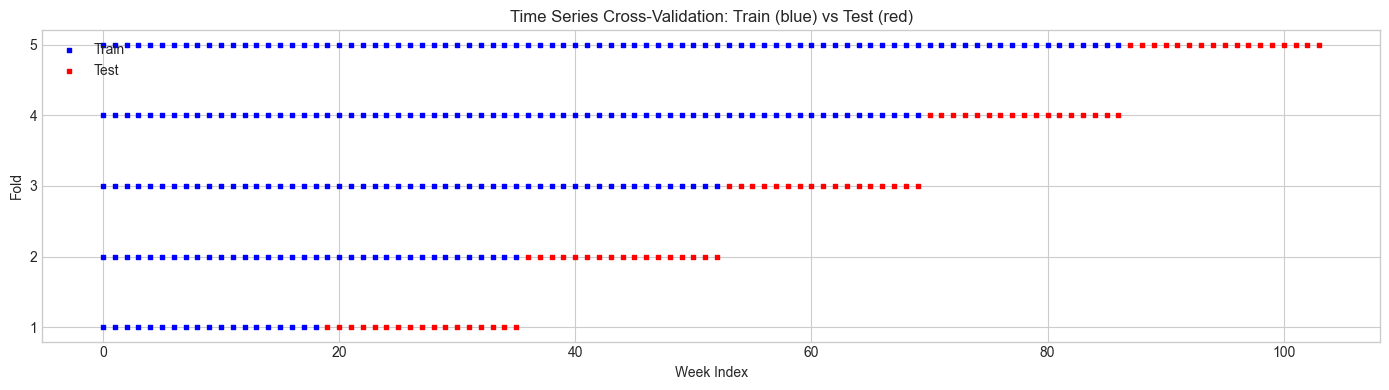

Each fold trains on past data only and tests on future data.
This simulates real-world forecasting where you can't see the future.


In [22]:
# Step 6d: Visualize the CV folds

fig, ax = plt.subplots(figsize=(14, 4))

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    # Plot training data
    ax.scatter(train_idx, [fold] * len(train_idx), c='blue', marker='s', s=10, label='Train' if fold == 1 else '')
    # Plot test data
    ax.scatter(test_idx, [fold] * len(test_idx), c='red', marker='s', s=10, label='Test' if fold == 1 else '')

ax.set_xlabel('Week Index')
ax.set_ylabel('Fold')
ax.set_title('Time Series Cross-Validation: Train (blue) vs Test (red)')
ax.set_yticks(range(1, 6))
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

print("Each fold trains on past data only and tests on future data.")
print("This simulates real-world forecasting where you can't see the future.")

## Pre-Modeling Checklist

**Controls included:**
- Seasonality (`season_sin`, `season_cos`)
- Trend (`trend`)
- Macro factors (`unemployment_rate`)
- Competitive pressure (`competitor_spend_index`)
- Holidays (`is_holiday_week`)

**Not controlled for (simplifications):**
- Price changes or promotions
- Product launches
- PR / earned media
- Sales team capacity

---
## 7. Regression Modeling

Two models are compared:
- **OLS** — provides interpretable coefficients with p-values and confidence intervals
- **Ridge** — adds L2 regularization to handle multicollinearity, with alpha selected via time-series cross-validation

The better-performing model on the test set is selected for final coefficient interpretation.

In [23]:
# Step 7a: Build OLS model using SIMPLE HOLDOUT

import statsmodels.api as sm

# Add constant for intercept
X_train_const = sm.add_constant(X_train_holdout)
X_test_const = sm.add_constant(X_test_holdout)

# Fit OLS model on training data
model_ols = sm.OLS(y_train_holdout, X_train_const).fit()

print("MODEL 1: OLS Regression (Simple Holdout 80/20 split)")
print("=" * 60)
print(model_ols.summary())

MODEL 1: OLS Regression (Simple Holdout 80/20 split)
                            OLS Regression Results                            
Dep. Variable:                  leads   R-squared:                       0.766
Model:                            OLS   Adj. R-squared:                  0.721
Method:                 Least Squares   F-statistic:                     17.33
Date:                Wed, 04 Feb 2026   Prob (F-statistic):           7.29e-17
Time:                        14:00:01   Log-Likelihood:                -300.93
No. Observations:                  83   AIC:                             629.9
Df Residuals:                      69   BIC:                             663.7
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

In [24]:
# Step 7b: Build Ridge Regression model to handle multicollinearity
# Ridge adds L2 penalty to shrink coefficients and reduce variance from multicollinearity

from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

# Standardize features for Ridge (important for regularization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_holdout)
X_test_scaled = scaler.transform(X_test_holdout)

# Use cross-validation to find optimal alpha (regularization strength)
# TimeSeriesSplit respects temporal order - avoids training on future data
alphas = np.logspace(-2, 4, 50)  # Range from 0.01 to 10000
tscv = TimeSeriesSplit(n_splits=5)
ridge_cv = RidgeCV(alphas=alphas, cv=tscv)
ridge_cv.fit(X_train_scaled, y_train_holdout)

print("MODEL 2: Ridge Regression (with CV for alpha selection)")
print("=" * 60)
print(f"Optimal alpha: {ridge_cv.alpha_:.4f}")
print(f"Training R²: {ridge_cv.score(X_train_scaled, y_train_holdout):.4f}")
print(f"\nRidge coefficients (scaled features):")

ridge_coef_df = pd.DataFrame({
    'Feature': X_train_holdout.columns,
    'Ridge_Coefficient': ridge_cv.coef_
}).sort_values('Ridge_Coefficient', key=abs, ascending=False)

display(ridge_coef_df)

MODEL 2: Ridge Regression (with CV for alpha selection)
Optimal alpha: 4.9417
Training R²: 0.7623

Ridge coefficients (scaled features):


,Feature,Ridge_Coefficient
7,season_sin,14.178677
2,paid_search_spend_adstock_saturated,5.391891
9,trend,-2.281686
6,seo_investment_adstock_saturated,2.137066
3,paid_social_spend_adstock_saturated,1.405330
11,competitor_spend_index,-1.236747
0,tv_spend_adstock_saturated,1.053518
12,is_holiday_week,1.013267
8,season_cos,0.825494
1,radio_spend_adstock_saturated,0.819044


In [25]:
# Step 7c: Compare OLS vs Ridge on TEST SET

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# OLS predictions
y_pred_ols = model_ols.predict(X_test_const)
r2_ols = r2_score(y_test_holdout, y_pred_ols)
mae_ols = mean_absolute_error(y_test_holdout, y_pred_ols)
rmse_ols = np.sqrt(mean_squared_error(y_test_holdout, y_pred_ols))

# Ridge predictions
y_pred_ridge = ridge_cv.predict(X_test_scaled)
r2_ridge = r2_score(y_test_holdout, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test_holdout, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test_holdout, y_pred_ridge))

print("MODEL COMPARISON ON TEST SET")
print("=" * 60)
print(f"{'Metric':<20} {'OLS':>15} {'Ridge':>15}")
print("-" * 60)
print(f"{'R² (train)':<20} {model_ols.rsquared:>15.4f} {ridge_cv.score(X_train_scaled, y_train_holdout):>15.4f}")
print(f"{'R² (test)':<20} {r2_ols:>15.4f} {r2_ridge:>15.4f}")
print(f"{'MAE':<20} {mae_ols:>15.2f} {mae_ridge:>15.2f}")
print(f"{'RMSE':<20} {rmse_ols:>15.2f} {rmse_ridge:>15.2f}")

# Select best model based on test R²
if r2_ridge > r2_ols:
    best_model_name = "Ridge"
    use_ridge = True
    print(f"\n>>> RIDGE performs better on test set (R² = {r2_ridge:.4f} vs {r2_ols:.4f})")
else:
    best_model_name = "OLS"
    use_ridge = False
    print(f"\n>>> OLS performs better on test set (R² = {r2_ols:.4f} vs {r2_ridge:.4f})")

print(f"\nUsing {best_model_name} for subsequent analysis (ROI, optimization).")

MODEL COMPARISON ON TEST SET
Metric                           OLS           Ridge
------------------------------------------------------------
R² (train)                    0.7655          0.7623
R² (test)                    -0.2169         -0.0894
MAE                             9.83            9.34
RMSE                           12.15           11.50

>>> RIDGE performs better on test set (R² = -0.0894 vs -0.2169)

Using Ridge for subsequent analysis (ROI, optimization).


---
> **Note:** Model fit is modest due to the synthetic data. With real marketing data, R² values in the 0.6–0.9 range are typical for well-specified MMMs.

In [26]:
# Step 7d: Train final model on ALL data for coefficient interpretation
# We'll train both OLS and Ridge on all data

# OLS on all data
X_all_const = sm.add_constant(X)
model_final_ols = sm.OLS(y, X_all_const).fit()

# Ridge on all data (using same alpha found in CV)
X_all_scaled = scaler.fit_transform(X)
from sklearn.linear_model import Ridge
model_final_ridge = Ridge(alpha=ridge_cv.alpha_)
model_final_ridge.fit(X_all_scaled, y)

print("FINAL MODELS (trained on all data for coefficient interpretation)")
print("=" * 60)

# Create marketing_coef dict based on selected model
# This will be used in Steps 9 and 10 for ROI calculations
if use_ridge:
    print(f"Using RIDGE (alpha={ridge_cv.alpha_:.4f}) for ROI calculations")

    # Convert Ridge coefficients back to original (unscaled) feature space
    # Ridge was fit on standardized features, so: coef_original = coef_scaled / feature_std
    feature_stds = scaler.scale_  # Standard deviations used for scaling
    coef_original = model_final_ridge.coef_ / feature_stds

    # Create dict mapping feature names to original-scale coefficients
    all_coef_dict = dict(zip(X.columns, coef_original))
    marketing_coef = {col: all_coef_dict[col] for col in marketing_cols}

    print("\nRidge coefficients (converted to original scale for ROI calculation):")
    final_coef_df = pd.DataFrame({
        'Feature': X.columns,
        'Coef (scaled)': model_final_ridge.coef_,
        'Coef (original)': coef_original
    }).sort_values('Coef (original)', key=abs, ascending=False)
    display(final_coef_df)
else:
    print("Using OLS for ROI calculations")
    marketing_coef = model_final_ols.params[[col for col in marketing_cols]].to_dict()
    print(model_final_ols.summary())

print(f"\nMarketing coefficients stored for ROI analysis ({len(marketing_coef)} channels)")

FINAL MODELS (trained on all data for coefficient interpretation)
Using RIDGE (alpha=4.9417) for ROI calculations

Ridge coefficients (converted to original scale for ROI calculation):


,Feature,Coef (scaled),Coef (original)
2,paid_search_spend_adstock_saturated,5.221935,255.667974
6,seo_investment_adstock_saturated,2.185351,160.242586
0,tv_spend_adstock_saturated,1.427151,94.879770
3,paid_social_spend_adstock_saturated,0.786397,25.556011
7,season_sin,14.309095,20.336402
1,radio_spend_adstock_saturated,-0.430099,-16.577823
4,ooh_spend_adstock_saturated,0.176088,8.030384
5,ott_spend_adstock_saturated,-0.048654,-2.157027
8,season_cos,1.374815,1.935025
12,is_holiday_week,0.689074,1.716525



Marketing coefficients stored for ROI analysis (7 channels)


In [27]:
# Step 7e: Understanding Hill function coefficients
print("INTERPRETING HILL FUNCTION COEFFICIENTS")
print("=" * 60)
print("""
Hill saturation transforms spend into a 0-1 scale representing "fraction of max effect".

Coefficient interpretation:
- B = total leads attributed when channel goes from 0% to 100% saturation
- NOT directly interpretable as "X leads per dollar" (that's marginal ROI in Step 10)

Example: If TV coefficient = 500 and current Hill output = 0.7:
- TV is at 70% of its maximum potential effect
- Increasing to 100% saturation would add ~150 more leads (500 x 0.3)
- But reaching 100% saturation requires disproportionately more spend (diminishing returns)

For actionable insights, use MARGINAL ROI (Step 10) which accounts for current saturation level.
""")

INTERPRETING HILL FUNCTION COEFFICIENTS

Hill saturation transforms spend into a 0-1 scale representing "fraction of max effect".

Coefficient interpretation:
- B = total leads attributed when channel goes from 0% to 100% saturation
- NOT directly interpretable as "X leads per dollar" (that's marginal ROI in Step 10)

Example: If TV coefficient = 500 and current Hill output = 0.7:
- TV is at 70% of its maximum potential effect
- Increasing to 100% saturation would add ~150 more leads (500 x 0.3)
- But reaching 100% saturation requires disproportionately more spend (diminishing returns)

For actionable insights, use MARGINAL ROI (Step 10) which accounts for current saturation level.



---
## 8. Model Diagnostics

Key diagnostic checks:
1. **Holdout R²** — generalization beyond training data
2. **Residual analysis** — normality, heteroskedasticity, autocorrelation
3. **Newey-West HAC standard errors** — robust inference under autocorrelation
4. **VIF** — multicollinearity assessment (VIF > 5 warrants attention, > 10 is problematic)
5. **Coefficient signs** — economic plausibility (negative marketing coefficients are red flags)

In [28]:
# Step 8a: Test set performance summary

print("MODEL PERFORMANCE SUMMARY")
print("=" * 60)

print(f"\nOLS MODEL:")
print(f"  R² (train): {model_ols.rsquared:.4f}")
print(f"  R² (test):  {r2_ols:.4f}")
print(f"  MAE: {mae_ols:.2f} leads")
print(f"  RMSE: {rmse_ols:.2f} leads")

print(f"\nRIDGE MODEL (alpha={ridge_cv.alpha_:.4f}):")
print(f"  R² (train): {ridge_cv.score(X_train_scaled, y_train_holdout):.4f}")
print(f"  R² (test):  {r2_ridge:.4f}")
print(f"  MAE: {mae_ridge:.2f} leads")
print(f"  RMSE: {rmse_ridge:.2f} leads")

print(f"\n>>> Selected model: {best_model_name}")

print("\nINTERPRETATION:")
best_r2 = r2_ridge if use_ridge else r2_ols
if best_r2 < 0:
    print("  Note: Negative test R² indicates the model predicts worse than the mean.")
    print("  This is common with synthetic data - real datasets typically perform better.")
else:
    print(f"  Model explains {best_r2*100:.1f}% of variance in test set.")

MODEL PERFORMANCE SUMMARY

OLS MODEL:
  R² (train): 0.7655
  R² (test):  -0.2169
  MAE: 9.83 leads
  RMSE: 12.15 leads

RIDGE MODEL (alpha=4.9417):
  R² (train): 0.7623
  R² (test):  -0.0894
  MAE: 9.34 leads
  RMSE: 11.50 leads

>>> Selected model: Ridge

INTERPRETATION:
  Note: Negative test R² indicates the model predicts worse than the mean.
  This is common with synthetic data - real datasets typically perform better.


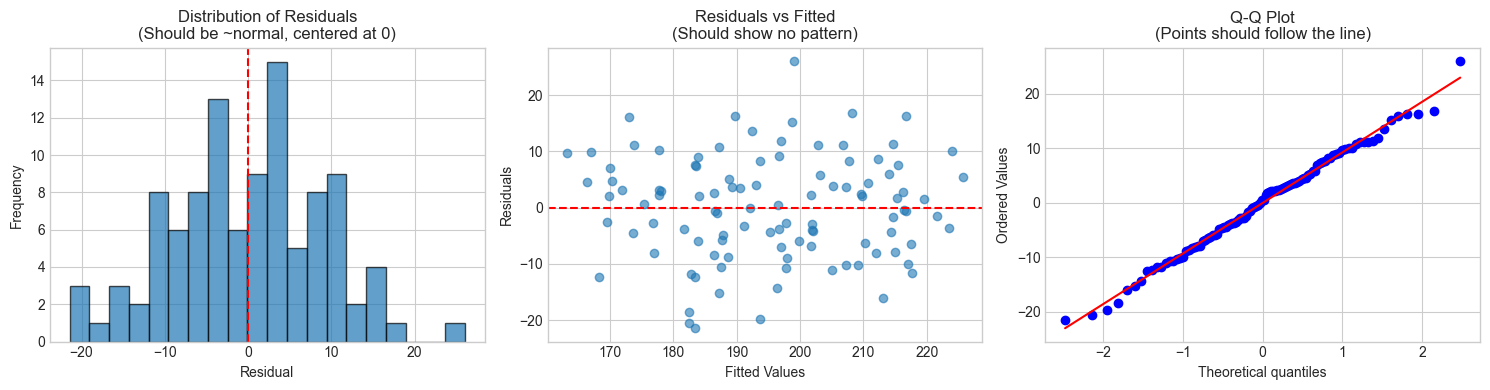

Shapiro-Wilk test for normality: p-value = 0.8830
  Residuals appear normally distributed (p > 0.05)

Ljung-Box Test for Autocorrelation:
H0: No autocorrelation up to lag k


,lb_stat,lb_pvalue
1,3.636592,0.056523
5,14.977254,0.010460
10,17.144614,0.071225



  - Adding lagged dependent variable
  - Using Newey-West standard errors
  - Checking for omitted seasonality


In [29]:
# Step 8b: Residual analysis
# Using OLS model for residual diagnostics (easier to interpret)

residuals = model_final_ols.resid
fitted_values = model_final_ols.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram of residuals
axes[0].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Residuals\n(Should be ~normal, centered at 0)')

# Residuals vs Fitted values
axes[1].scatter(fitted_values, residuals, alpha=0.6)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Fitted\n(Should show no pattern)')

# Q-Q plot for normality
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot\n(Points should follow the line)')

plt.tight_layout()
plt.show()

# Statistical test for normality
_, p_value = stats.shapiro(residuals)
print(f"Shapiro-Wilk test for normality: p-value = {p_value:.4f}")
if p_value > 0.05:
    print("  Residuals appear normally distributed (p > 0.05)")
else:
    print("  Residuals may not be normally distributed (p < 0.05)")


# Ljung-Box test for autocorrelation in residuals
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_results = acorr_ljungbox(residuals, lags=[1, 5, 10], return_df=True)
print('\nLjung-Box Test for Autocorrelation:')
print('H0: No autocorrelation up to lag k')
display(lb_results)

if (lb_results['lb_pvalue'] < 0.05).any():
    print('\nWARNING: Significant autocorrelation detected. Consider:')
    print('  - Adding lagged dependent variable')
    print('  - Using Newey-West standard errors')
    print('  - Checking for omitted seasonality')
else:
    print('\nNo significant autocorrelation detected (p > 0.05 for all lags)')


In [30]:
# Step 8c: Newey-West HAC standard errors (robust to autocorrelation & heteroskedasticity)

# Refit with HAC standard errors
model_hac = sm.OLS(y, X_all_const).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

print('OLS with Newey-West HAC Standard Errors')
print('(Robust to autocorrelation and heteroskedasticity)')
print('-' * 60)

# Compare standard errors
se_comparison = pd.DataFrame({
    'Feature': model_final_ols.params.index,
    'Coef': model_final_ols.params.values,
    'SE (OLS)': model_final_ols.bse.values,
    'SE (HAC)': model_hac.bse.values,
    'SE Ratio': model_hac.bse.values / model_final_ols.bse.values
})
display(se_comparison.round(4))

if (se_comparison['SE Ratio'] > 1.5).any():
    print('\nNote: HAC standard errors are >50% larger for some coefficients.')
    print('This suggests OLS may underestimate uncertainty due to autocorrelation.')


OLS with Newey-West HAC Standard Errors
(Robust to autocorrelation and heteroskedasticity)
------------------------------------------------------------


,Feature,Coef,SE (OLS),SE (HAC),SE Ratio
0,const,-86.4494,59.4865,78.6345,1.3219
1,tv_spend_adstock_saturated,127.0593,81.5181,102.5420,1.2579
2,radio_spend_adstock_saturated,-18.1297,44.0224,39.1391,0.8891
3,paid_search_spend_adstock_saturated,275.4468,50.6568,47.7657,0.9429
4,paid_social_spend_adstock_saturated,27.3992,34.1974,27.1096,0.7927
5,ooh_spend_adstock_saturated,11.0919,52.4190,39.9860,0.7628
6,ott_spend_adstock_saturated,-15.5606,48.9133,41.5280,0.8490
7,seo_investment_adstock_saturated,166.4146,74.6347,51.6932,0.6926
8,season_sin,21.7947,1.6424,1.3363,0.8136
9,season_cos,2.0354,1.4750,1.0833,0.7344


In [31]:
# Step 8d: Calculate VIF (Variance Inflation Factor) for multicollinearity
# VIF > 5 = potential problem, VIF > 10 = serious multicollinearity

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

# Add interpretation
def vif_interpretation(vif):
    if vif > 10:
        return "SERIOUS"
    elif vif > 5:
        return "MODERATE"
    else:
        return "OK"

vif_data['Status'] = vif_data['VIF'].apply(vif_interpretation)

print("VARIANCE INFLATION FACTORS (VIF)")
print("=" * 60)
print("VIF > 5: potential multicollinearity")
print("VIF > 10: serious multicollinearity")
print()
display(vif_data)

# Summary
serious = (vif_data['VIF'] > 10).sum()
moderate = ((vif_data['VIF'] > 5) & (vif_data['VIF'] <= 10)).sum()
print(f"\nSummary: {serious} serious, {moderate} moderate multicollinearity issues")

VARIANCE INFLATION FACTORS (VIF)
VIF > 5: potential multicollinearity
VIF > 10: serious multicollinearity



,Feature,VIF,Status
0,tv_spend_adstock_saturated,1389.810734,SERIOUS
1,seo_investment_adstock_saturated,1044.978760,SERIOUS
2,ooh_spend_adstock_saturated,729.957127,SERIOUS
3,ott_spend_adstock_saturated,639.485425,SERIOUS
4,paid_search_spend_adstock_saturated,560.336173,SERIOUS
5,radio_spend_adstock_saturated,488.056628,SERIOUS
6,paid_social_spend_adstock_saturated,302.625278,SERIOUS
7,competitor_spend_index,73.942113,SERIOUS
8,unemployment_rate,47.593903,SERIOUS
9,trend,5.026057,MODERATE



Summary: 9 serious, 1 moderate multicollinearity issues


In [32]:
# Step 8e: Check coefficient signs - do they make business sense?
# Note: This analysis uses OLS coefficients because Ridge doesn't provide p-values.
# Sign direction should be similar between models.

# Extract coefficients from OLS model
coef_df = pd.DataFrame({
    'Feature': model_final_ols.params.index,
    'Coefficient': model_final_ols.params.values,
    'P-Value': model_final_ols.pvalues.values
})

# Expected signs for marketing channels (all should be positive)
expected_signs = {
    'tv_spend_adstock_saturated': '+',
    'radio_spend_adstock_saturated': '+',
    'paid_search_spend_adstock_saturated': '+',
    'paid_social_spend_adstock_saturated': '+',
    'ooh_spend_adstock_saturated': '+',
    'ott_spend_adstock_saturated': '+',
    'seo_investment_adstock_saturated': '+',
    'season_sin': '+/-',  # can be either
    'season_cos': '+/-',
    'trend': '+/-',
    'unemployment_rate': '-',  # higher unemployment = fewer leads
    'competitor_spend_index': '-',  # more competitor spend = fewer leads
    'is_holiday_week': '+/-',  # could go either way
    'const': '+/-'
}

coef_df['Expected'] = coef_df['Feature'].map(expected_signs)
coef_df['Actual'] = coef_df['Coefficient'].apply(lambda x: '+' if x > 0 else '-')
coef_df['Significant'] = coef_df['P-Value'].apply(lambda p: 'Yes' if p < 0.05 else 'No')

# Flag sign issues for marketing channels
def check_sign(row):
    if row['Expected'] == '+/-':
        return 'OK'
    elif pd.isna(row['Expected']):
        return 'OK'
    elif row['Expected'] == row['Actual']:
        return 'OK'
    else:
        return 'UNEXPECTED'

coef_df['Sign Check'] = coef_df.apply(check_sign, axis=1)

print("COEFFICIENT SIGN ANALYSIS (OLS - used for p-value diagnostics)")
print("=" * 60)
if use_ridge:
    print(f"Note: ROI calculations use Ridge coefficients; this shows OLS for significance testing")
print("Marketing channels should have POSITIVE coefficients")
print("(more spend = more leads)")
print()
display(coef_df[['Feature', 'Coefficient', 'Expected', 'Actual', 'Sign Check', 'Significant']].round(4))

# Flag any issues
unexpected = coef_df[(coef_df['Sign Check'] == 'UNEXPECTED') & (coef_df['Significant'] == 'Yes')]
if len(unexpected) > 0:
    print("\nWARNING: These significant coefficients have unexpected signs:")
    for _, row in unexpected.iterrows():
        print(f"  {row['Feature']}: {row['Coefficient']:.4f} (expected {row['Expected']}, got {row['Actual']})")
else:
    print("\nNo significant coefficients with unexpected signs.")

COEFFICIENT SIGN ANALYSIS (OLS - used for p-value diagnostics)
Note: ROI calculations use Ridge coefficients; this shows OLS for significance testing
Marketing channels should have POSITIVE coefficients
(more spend = more leads)



,Feature,Coefficient,Expected,Actual,Sign Check,Significant
0,const,-86.4494,+/-,-,OK,No
1,tv_spend_adstock_saturated,127.0593,+,+,OK,No
2,radio_spend_adstock_saturated,-18.1297,+,-,UNEXPECTED,No
3,paid_search_spend_adstock_saturated,275.4468,+,+,OK,Yes
4,paid_social_spend_adstock_saturated,27.3992,+,+,OK,No
5,ooh_spend_adstock_saturated,11.0919,+,+,OK,No
6,ott_spend_adstock_saturated,-15.5606,+,-,UNEXPECTED,No
7,seo_investment_adstock_saturated,166.4146,+,+,OK,Yes
8,season_sin,21.7947,+/-,+,OK,Yes
9,season_cos,2.0354,+/-,+,OK,No



No significant coefficients with unexpected signs.


---
## 9. Channel ROI Estimation

Channel contributions are decomposed from model coefficients and converted to ROI (return on investment) and ROAS (return on ad spend). These estimates reflect average effectiveness over the modeling period.

In [33]:
# Step 9a: Calculate revenue per lead conversion factor
# This lets us convert attributed leads → attributed revenue

total_revenue = df['revenue'].sum()
total_leads = df['leads'].sum()
revenue_per_lead = total_revenue / total_leads

print("REVENUE PER LEAD CONVERSION FACTOR")
print("=" * 60)
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Leads: {total_leads:,}")
print(f"Revenue per Lead: ${revenue_per_lead:,.2f}")
print("\nThis factor converts attributed leads to attributed revenue.")

REVENUE PER LEAD CONVERSION FACTOR
Total Revenue: $33,416,027.00
Total Leads: 20,332
Revenue per Lead: $1,643.52

This factor converts attributed leads to attributed revenue.


In [34]:
# Step 9b: Decompose leads by channel using model coefficients
# Contribution = coefficient * sum(transformed_feature_values)

# marketing_coef was already created in Step 7d based on selected model (OLS or Ridge)
# It contains coefficients on the original (unscaled) feature space

# Calculate contribution of each channel
channel_contributions = {}
for col in marketing_cols:
    # Contribution = coefficient * sum of transformed feature values
    contribution = marketing_coef[col] * df[col].sum()
    # Clean channel name
    channel_name = col.replace('_adstock_saturated', '').replace('_spend', '').replace('_investment', '')
    channel_contributions[channel_name] = max(contribution, 0)  # Floor at 0 (negative contribution doesn't make sense)

# Calculate total marketing-attributed leads
total_attributed_leads = sum(channel_contributions.values())

# Normalize to actual total leads (intercept + controls explain the rest)
# This is a simplification - in practice, we'd use proper decomposition
scaling_factor = total_leads / total_attributed_leads if total_attributed_leads > 0 else 1

print("LEAD ATTRIBUTION BY CHANNEL")
print("=" * 60)
print(f"Using {'Ridge' if use_ridge else 'OLS'} coefficients for attribution")
print()
print(f"{'Channel':<20} {'Raw Contribution':<18} {'Attributed Leads':<18}")
print("-" * 60)

attributed_leads_by_channel = {}
for channel, contrib in sorted(channel_contributions.items(), key=lambda x: x[1], reverse=True):
    attributed = contrib  # Raw contribution represents attributed leads
    attributed_leads_by_channel[channel] = attributed
    print(f"{channel.upper():<20} {contrib:>15,.1f}   {attributed:>15,.1f}")

print("-" * 60)
print(f"{'TOTAL':<20} {total_attributed_leads:>15,.1f}   {sum(attributed_leads_by_channel.values()):>15,.1f}")

LEAD ATTRIBUTION BY CHANNEL
Using Ridge coefficients for attribution

Channel              Raw Contribution   Attributed Leads  
------------------------------------------------------------
PAID_SEARCH                 13,228.3          13,228.3
SEO                          8,328.9           8,328.9
TV                           4,921.7           4,921.7
PAID_SOCIAL                  1,326.5           1,326.5
OOH                            414.3             414.3
RADIO                            0.0               0.0
OTT                              0.0               0.0
------------------------------------------------------------
TOTAL                       28,219.8          28,219.8


In [35]:
# Step 9c: Calculate ROI by channel
# ROI = (Attributed Revenue - Spend) / Spend = (Attributed Revenue / Spend) - 1
# Or simply: ROAS = Attributed Revenue / Spend

# Map channel names to spend columns
channel_spend_map = {
    'tv': 'tv_spend',
    'radio': 'radio_spend',
    'paid_search': 'paid_search_spend',
    'paid_social': 'paid_social_spend',
    'ooh': 'ooh_spend',
    'ott': 'ott_spend',
    'seo': 'seo_investment'
}

roi_data = []
for channel, attributed_leads in attributed_leads_by_channel.items():
    spend_col = channel_spend_map.get(channel)
    if spend_col:
        total_spend = df[spend_col].sum()
        attributed_revenue = attributed_leads * revenue_per_lead
        
        if total_spend > 0:
            roas = attributed_revenue / total_spend
            roi = (attributed_revenue - total_spend) / total_spend
        else:
            roas = 0
            roi = 0
            
        roi_data.append({
            'Channel': channel.upper(),
            'Total Spend': total_spend,
            'Attributed Leads': attributed_leads,
            'Attributed Revenue': attributed_revenue,
            'ROAS': roas,
            'ROI': roi
        })

roi_df = pd.DataFrame(roi_data).sort_values('ROI', ascending=False)

print("ROI BY CHANNEL")
print("=" * 80)
print(f"Revenue per Lead: ${revenue_per_lead:,.2f}")
print()
display(roi_df.style.format({
    'Total Spend': '${:,.0f}',
    'Attributed Leads': '{:,.1f}',
    'Attributed Revenue': '${:,.0f}',
    'ROAS': '{:.2f}x',
    'ROI': '{:.1%}'
}))

print("\nInterpretation:")
print("  ROAS = Return on Ad Spend (revenue per dollar spent)")
print("  ROI = (Revenue - Spend) / Spend (profit margin on spend)")
print("  ROAS > 1 means revenue exceeds spend; ROI > 0% means profitable")

ROI BY CHANNEL
Revenue per Lead: $1,643.52



,Channel,Total Spend,Attributed Leads,Attributed Revenue,ROAS,ROI
1,SEO,"$311,373","8,328.9","$13,688,692",43.96x,4296.2%
0,PAID_SEARCH,"$1,619,584","13,228.3","$21,741,016",13.42x,1242.4%
3,PAID_SOCIAL,"$620,657","1,326.5","$2,180,174",3.51x,251.3%
2,TV,"$2,794,825","4,921.7","$8,088,915",2.89x,189.4%
4,OOH,"$411,082",414.3,"$680,898",1.66x,65.6%
5,RADIO,"$859,783",0.0,$0,0.00x,-100.0%
6,OTT,"$536,601",0.0,$0,0.00x,-100.0%



Interpretation:
  ROAS = Return on Ad Spend (revenue per dollar spent)
  ROI = (Revenue - Spend) / Spend (profit margin on spend)
  ROAS > 1 means revenue exceeds spend; ROI > 0% means profitable


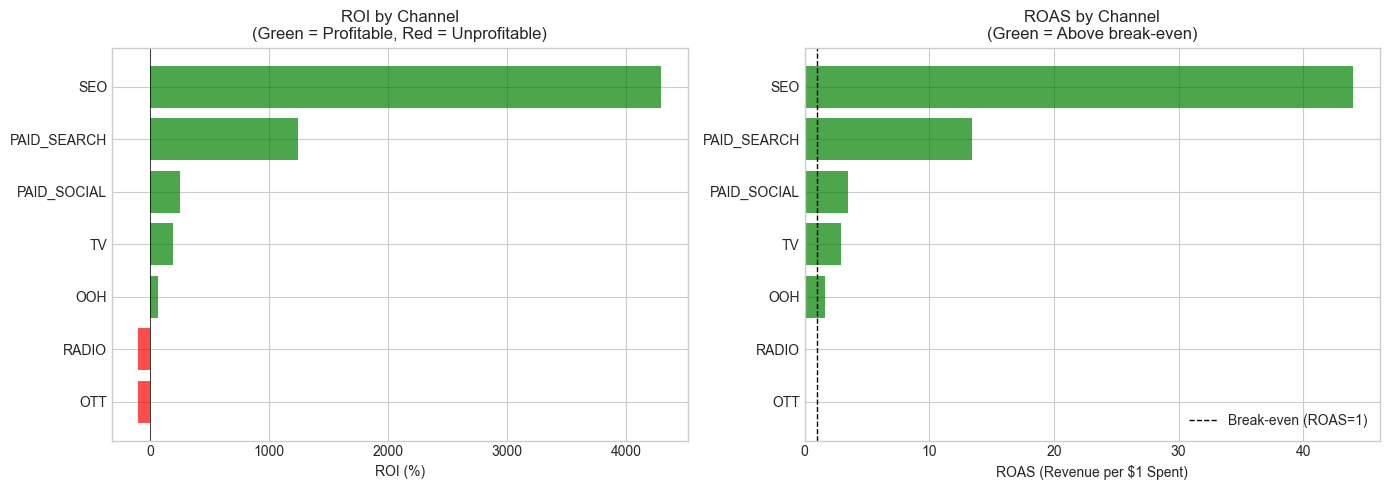


Profitable channels (ROI > 0): SEO, PAID_SEARCH, PAID_SOCIAL, TV, OOH
Unprofitable channels (ROI <= 0): RADIO, OTT


In [36]:
# Step 9d: Visualize ROI by channel

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sort by ROI for visualization
roi_df_sorted = roi_df.sort_values('ROI', ascending=True)

# Bar chart of ROI
colors = ['green' if x > 0 else 'red' for x in roi_df_sorted['ROI']]
axes[0].barh(roi_df_sorted['Channel'], roi_df_sorted['ROI'] * 100, color=colors, alpha=0.7)
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[0].set_xlabel('ROI (%)')
axes[0].set_title('ROI by Channel\n(Green = Profitable, Red = Unprofitable)')

# Bar chart of ROAS
colors_roas = ['green' if x > 1 else 'red' for x in roi_df_sorted['ROAS']]
axes[1].barh(roi_df_sorted['Channel'], roi_df_sorted['ROAS'], color=colors_roas, alpha=0.7)
axes[1].axvline(x=1, color='black', linestyle='--', linewidth=1, label='Break-even (ROAS=1)')
axes[1].set_xlabel('ROAS (Revenue per $1 Spent)')
axes[1].set_title('ROAS by Channel\n(Green = Above break-even)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Summary statistics
positive_roi_channels = roi_df[roi_df['ROI'] > 0]['Channel'].tolist()
negative_roi_channels = roi_df[roi_df['ROI'] <= 0]['Channel'].tolist()

print(f"\nProfitable channels (ROI > 0): {', '.join(positive_roi_channels) if positive_roi_channels else 'None'}")
print(f"Unprofitable channels (ROI <= 0): {', '.join(negative_roi_channels) if negative_roi_channels else 'None'}")

---
## 10. Budget Optimization

Average ROI can be misleading — a channel with high average ROI may already be saturated. Marginal ROI (the return on the *next* dollar) accounts for where each channel sits on its saturation curve and is the appropriate metric for reallocation decisions.

The Hill function derivative gives the marginal effect at current spend levels, which is then converted to marginal revenue per dollar.

In [37]:
# Step 10a: Calculate marginal ROI using Hill function derivative
# Marginal ROI tells us the return on the NEXT dollar spent (accounts for saturation)

def hill_derivative(x, alpha=0.5, K=None):
    """
    Derivative of Hill function: d/dx [x^alpha / (x^alpha + K^alpha)]
    = alpha * K^alpha * x^(alpha-1) / (x^alpha + K^alpha)^2
    
    This gives us the marginal effect at spend level x.
    """
    if K is None:
        K = np.median(x)
    numerator = alpha * (K ** alpha) * (x ** (alpha - 1))
    denominator = (x ** alpha + K ** alpha) ** 2
    return numerator / denominator

# Calculate marginal effect for each channel at current spend levels
marginal_data = []

for channel, spend_col in channel_spend_map.items():
    # Get current average weekly spend
    current_spend = df[spend_col].mean()
    
    # Get adstock column and calculate adstocked spend
    adstock_col = f"{spend_col}_adstock"
    current_adstock = df[adstock_col].mean()
    
    # Get the coefficient for this channel
    saturated_col = f"{spend_col}_adstock_saturated"
    if saturated_col in marketing_coef:
        coef = marketing_coef[saturated_col]
    else:
        coef = 0
    
    # Calculate K (half-saturation) - same as used in hill_transform
    K = np.median(df[adstock_col])
    
    # Marginal effect = coefficient * derivative of Hill function
    marginal_effect = coef * hill_derivative(current_adstock, alpha=0.5, K=K)
    
    # Convert to marginal ROI (leads per dollar → revenue per dollar)
    marginal_leads_per_dollar = marginal_effect
    marginal_revenue_per_dollar = marginal_leads_per_dollar * revenue_per_lead
    marginal_roi = marginal_revenue_per_dollar - 1  # Subtract 1 to get profit margin
    
    marginal_data.append({
        'Channel': channel.upper(),
        'Avg Weekly Spend': current_spend,
        'Coefficient': coef,
        'Marginal Effect': marginal_effect,
        'Marginal ROAS': marginal_revenue_per_dollar,
        'Marginal ROI': marginal_roi
    })

marginal_df = pd.DataFrame(marginal_data).sort_values('Marginal ROI', ascending=False)

print("MARGINAL ROI BY CHANNEL")
print("=" * 80)
print("Marginal ROI = return on the NEXT dollar spent (accounts for diminishing returns)")
print()
display(marginal_df.style.format({
    'Avg Weekly Spend': '${:,.0f}',
    'Coefficient': '{:.2f}',
    'Marginal Effect': '{:.6f}',
    'Marginal ROAS': '{:.4f}x',
    'Marginal ROI': '{:.2%}'
}))

MARGINAL ROI BY CHANNEL
Marginal ROI = return on the NEXT dollar spent (accounts for diminishing returns)



,Channel,Avg Weekly Spend,Coefficient,Marginal Effect,Marginal ROAS,Marginal ROI
6,SEO,"$2,994",160.24,0.004701,7.7258x,672.58%
2,PAID_SEARCH,"$15,573",255.67,0.001849,3.0391x,203.91%
3,PAID_SOCIAL,"$5,968",25.56,0.000482,0.7925x,-20.75%
0,TV,"$26,873",94.88,0.000179,0.2941x,-70.59%
4,OOH,"$3,953",8.03,0.000128,0.2101x,-78.99%
5,OTT,"$5,160",-2.16,-0.000026,-0.0433x,-104.33%
1,RADIO,"$8,267",-16.58,-0.000152,-0.2491x,-124.91%


BUDGET REALLOCATION OPPORTUNITIES

Channels to INCREASE (positive marginal ROI):
  SEO: Marginal ROI = 672.6%
  PAID_SEARCH: Marginal ROI = 203.9%

Channels to DECREASE (negative marginal ROI):
  OOH: Marginal ROI = -79.0%
  OTT: Marginal ROI = -104.3%
  RADIO: Marginal ROI = -124.9%


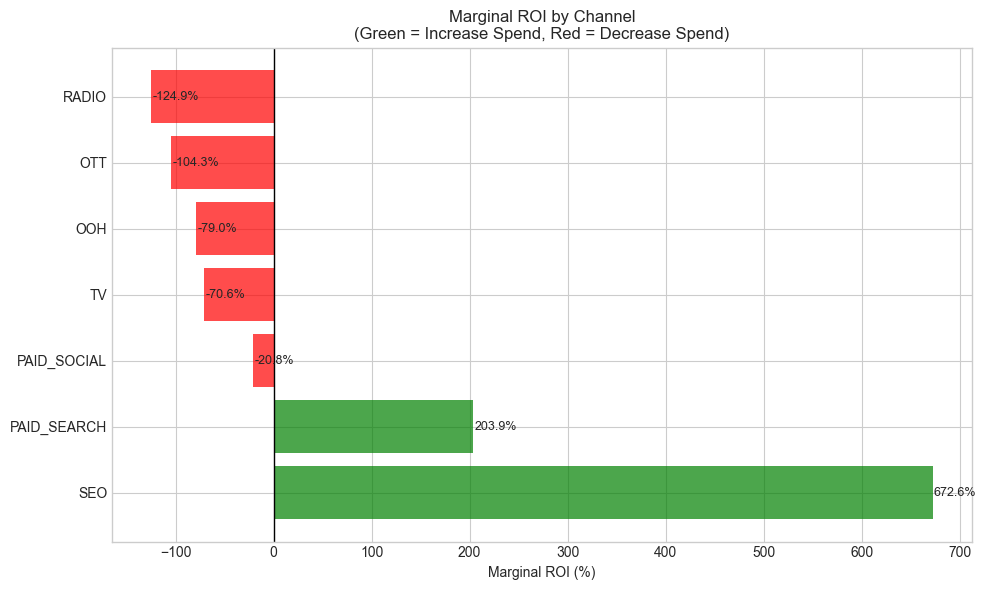

In [38]:
# Step 10b: Identify reallocation opportunities
# High marginal ROI → increase spend
# Low/negative marginal ROI → decrease spend

# Identify highest and lowest marginal ROI channels
highest_mroi = marginal_df.iloc[0]
lowest_mroi = marginal_df.iloc[-1]

print("BUDGET REALLOCATION OPPORTUNITIES")
print("=" * 80)

# Channels to increase (positive marginal ROI, sorted by highest)
increase_channels = marginal_df[marginal_df['Marginal ROI'] > 0].head(3)
if len(increase_channels) > 0:
    print("\nChannels to INCREASE (positive marginal ROI):")
    for _, row in increase_channels.iterrows():
        print(f"  {row['Channel']}: Marginal ROI = {row['Marginal ROI']:.1%}")
else:
    print("\nNo channels with positive marginal ROI.")

# Channels to decrease (negative marginal ROI or lowest)
decrease_channels = marginal_df[marginal_df['Marginal ROI'] < 0].tail(3)
if len(decrease_channels) > 0:
    print("\nChannels to DECREASE (negative marginal ROI):")
    for _, row in decrease_channels.iterrows():
        print(f"  {row['Channel']}: Marginal ROI = {row['Marginal ROI']:.1%}")
else:
    # Show lowest even if positive
    print("\nChannels with lowest marginal ROI (candidates for decrease):")
    for _, row in marginal_df.tail(3).iterrows():
        print(f"  {row['Channel']}: Marginal ROI = {row['Marginal ROI']:.1%}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['green' if x > 0 else 'red' for x in marginal_df['Marginal ROI']]
bars = ax.barh(marginal_df['Channel'], marginal_df['Marginal ROI'] * 100, color=colors, alpha=0.7)
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Marginal ROI (%)')
ax.set_title('Marginal ROI by Channel\n(Green = Increase Spend, Red = Decrease Spend)')

# Add value labels
for bar, val in zip(bars, marginal_df['Marginal ROI']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
            f'{val:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [39]:
# Step 10c: Simulate a budget reallocation scenario
# Shift budget from lowest marginal ROI channel to highest

# Get highest and lowest (with positive coefficient) channels
positive_mroi = marginal_df[marginal_df['Coefficient'] > 0]

if len(positive_mroi) >= 2:
    from_channel = positive_mroi.iloc[-1]  # Lowest marginal ROI (but positive coef)
    to_channel = positive_mroi.iloc[0]  # Highest marginal ROI
    
    # Shift 20% of "from" channel's budget to "to" channel
    shift_pct = 0.20
    shift_amount = from_channel['Avg Weekly Spend'] * shift_pct
    
    print("BUDGET REALLOCATION SIMULATION")
    print("=" * 80)
    print(f"\nScenario: Shift 20% of {from_channel['Channel']} budget to {to_channel['Channel']}")
    print(f"  Amount shifted: ${shift_amount:,.0f}/week")
    print()
    
    # Calculate expected impact using marginal effects
    # Lost leads from reducing "from" channel
    lost_leads = from_channel['Marginal Effect'] * shift_amount
    # Gained leads from increasing "to" channel
    gained_leads = to_channel['Marginal Effect'] * shift_amount
    # Net change
    net_leads = gained_leads - lost_leads
    net_revenue = net_leads * revenue_per_lead
    
    print(f"Expected Weekly Impact:")
    print(f"  Leads lost from {from_channel['Channel']} decrease: {lost_leads:,.2f}")
    print(f"  Leads gained from {to_channel['Channel']} increase: {gained_leads:,.2f}")
    print(f"  Net lead change: {net_leads:+,.2f}")
    print(f"  Net revenue change: ${net_revenue:+,.0f}")
    
    # Annualized impact
    print(f"\nAnnualized Impact (52 weeks):")
    print(f"  Net leads: {net_leads * 52:+,.0f}")
    print(f"  Net revenue: ${net_revenue * 52:+,.0f}")
    
    # Break-even analysis
    if net_revenue > 0:
        print(f"\n>>> This reallocation is expected to be PROFITABLE")
    else:
        print(f"\n>>> This reallocation is expected to REDUCE revenue")
else:
    print("Insufficient channels with positive coefficients for simulation.")

BUDGET REALLOCATION SIMULATION

Scenario: Shift 20% of OOH budget to SEO
  Amount shifted: $791/week

Expected Weekly Impact:
  Leads lost from OOH decrease: 0.10
  Leads gained from SEO increase: 3.72
  Net lead change: +3.62
  Net revenue change: $+5,941

Annualized Impact (52 weeks):
  Net leads: +188
  Net revenue: $+308,956

>>> This reallocation is expected to be PROFITABLE


In [40]:
# Step 10d: Write recommendations summary

print("=" * 80)
print("BUDGET OPTIMIZATION RECOMMENDATIONS")
print("=" * 80)

print("""
Based on the Marketing Mix Model analysis, here are the key recommendations:

1. CHANNEL PERFORMANCE INSIGHTS:
""")

# Top performers by ROI
top_3 = roi_df.head(3)
for i, (_, row) in enumerate(top_3.iterrows(), 1):
    print(f"   {i}. {row['Channel']}: ROI = {row['ROI']:.1%}, ROAS = {row['ROAS']:.2f}x")

print("""
2. BUDGET REALLOCATION STRATEGY:
   - Marginal ROI analysis accounts for diminishing returns at current spend levels
   - Focus on channels where the NEXT dollar spent has the highest return
   - Consider shifting budget from saturated (low marginal ROI) to unsaturated channels
""")

# Specific recommendations
if len(positive_mroi) >= 2:
    print(f"   Specific recommendation: Shift 10-20% from {from_channel['Channel']} to {to_channel['Channel']}")

print("""
3. CAVEATS & LIMITATIONS:
   - These are MODEL-BASED estimates, not guarantees
   - Results depend on data quality and model assumptions
   - External factors (seasonality, competition) may change effectiveness
   - Recommend A/B testing before major budget shifts
   
4. SUGGESTED NEXT STEPS:
   - Test the highest-impact reallocation with a controlled experiment
   - Monitor performance for 4-6 weeks before drawing conclusions
   - Revisit the model quarterly as market conditions change

""")

BUDGET OPTIMIZATION RECOMMENDATIONS

Based on the Marketing Mix Model analysis, here are the key recommendations:

1. CHANNEL PERFORMANCE INSIGHTS:

   1. SEO: ROI = 4296.2%, ROAS = 43.96x
   2. PAID_SEARCH: ROI = 1242.4%, ROAS = 13.42x
   3. PAID_SOCIAL: ROI = 251.3%, ROAS = 3.51x

2. BUDGET REALLOCATION STRATEGY:
   - Marginal ROI analysis accounts for diminishing returns at current spend levels
   - Focus on channels where the NEXT dollar spent has the highest return
   - Consider shifting budget from saturated (low marginal ROI) to unsaturated channels

   Specific recommendation: Shift 10-20% from OOH to SEO

3. CAVEATS & LIMITATIONS:
   - These are MODEL-BASED estimates, not guarantees
   - Results depend on data quality and model assumptions
   - External factors (seasonality, competition) may change effectiveness
   - Recommend A/B testing before major budget shifts

4. SUGGESTED NEXT STEPS:
   - Test the highest-impact reallocation with a controlled experiment
   - Monitor per